# Project 3 — Network Pulse: Count–Min Sketch for Data Streams

*Mining of Massive Datasets*

This notebook implements the **Count–Min Sketch (CMS)** — a compact, probabilistic
data structure for estimating item frequencies in a **data stream** using
*sub-linear* memory. We apply it to the classic streaming problem of counting
word frequencies over several **Project Gutenberg** books that are read
**one line at a time, one token at a time**.

**What this notebook delivers**

1. A from-scratch `CountMinSketch` class (no external sketch libraries).
2. A true streaming pipeline (generator-based, no full token list in memory).
3. Top-*k* frequent words via a lightweight heavy-hitter tracker.
4. Memory-usage analysis vs. an exact dictionary.
5. Validation of estimates against exact counts on a sample, including the
   one-sided error guarantee `est ≥ exact` and the `error ≤ ε·N` bound.
6. A parameter sweep showing the memory–accuracy trade-off.

**Ground rules honoured here**

- Core algorithm implemented from scratch with **universal hashing**
  `h_i(x) = ((a_i·x + b_i) mod p) mod w`.
- A **stable, reproducible token→integer** step (a polynomial hash) is used
  *instead of* Python's built-in `hash()`, which is salted per-process.
- Deterministic, seeded `a_i`, `b_i` (fixed `seed`) → identical results every run.
- Only `numpy`, `pandas`, `matplotlib`, `scipy`, and the Python standard library.
- Exact counting appears **only** for validation and memory comparison, never as
  the main counting mechanism.


## 1. Setup and configuration

All tunable parameters live in this single cell for reproducibility. Given a
target error fraction `ε` and failure probability `δ`, the sketch dimensions are

$$w = \left\lceil \frac{e}{\varepsilon} \right\rceil, \qquad d = \left\lceil \ln\frac{1}{\delta} \right\rceil.$$

The resulting guarantee is: for any item, the estimate never *under*-counts, and
with probability at least `1 − δ` the *over*-count is at most `ε·N`, where `N`
is the total number of tokens seen.


In [1]:
import math
import os
import re
import sys
import time
import heapq
import platform
import urllib.request
from collections import Counter

import numpy as np
import pandas as pd
import scipy
import matplotlib
import matplotlib.pyplot as plt

# ---- Configuration -------------------------------------------------------
SEED     = 42       # master seed -> deterministic hash parameters & sampling
EPSILON  = 0.001    # target error fraction: over-count <= EPSILON * N
DELTA    = 0.01     # failure probability for the error bound
TOP_K    = 20       # number of top frequent words to report
DATA_DIR = "data"   # local cache for downloaded books

os.makedirs(DATA_DIR, exist_ok=True)
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["axes.grid"] = True

print("Environment")
print("-----------")
print(f"Python      : {platform.python_version()}")
print(f"numpy       : {np.__version__}")
print(f"pandas      : {pd.__version__}")
print(f"scipy       : {scipy.__version__}")
print(f"matplotlib  : {matplotlib.__version__}")
print()
print(f"SEED={SEED}  EPSILON={EPSILON}  DELTA={DELTA}  TOP_K={TOP_K}")

Environment
-----------
Python      : 3.14.5
numpy       : 2.5.0
pandas      : 3.0.3
scipy       : 1.18.0
matplotlib  : 3.11.0

SEED=42  EPSILON=0.001  DELTA=0.01  TOP_K=20


## 2. Motivation — why exact counting is expensive in streams

Imagine a firehose of events: words in a text feed, IP packets, search queries,
clicks. We want the frequency of each distinct item. The obvious approach is a
**hash map** `item -> count`.

The problem is memory. An exact dictionary grows with the number of **distinct**
items. For a web-scale stream (billions of distinct URLs, IPs, or n-grams) the
map cannot fit in RAM, and its size is *unpredictable* — it depends on the data,
not on a budget we choose in advance.

A **Count–Min Sketch** flips this around:

| Property            | Exact dictionary          | Count–Min Sketch            |
|---------------------|---------------------------|-----------------------------|
| Memory              | grows with #distinct items| **fixed** `d·w` counters    |
| Answer for frequent items | exact               | small, bounded over-count   |
| Under-count?        | never                     | **never** (one-sided error) |
| Per-item update     | O(1) amortised            | O(d)                        |
| Can list all items? | yes                       | no (needs a helper tracker) |

We accept a tiny, *provably bounded* over-estimate in exchange for **constant,
tunable memory** — exactly the trade the "massive datasets" setting demands.


## 3. Count–Min Sketch — theory

**Structure.** A `d × w` table `C` of integer counters, all zero initially,
plus `d` independent hash functions `h_0, …, h_{d-1}`, each mapping an item to a
column in `{0, …, w-1}`.

**Update** (`add item x`, weight 1): for every row `i`,
`C[i, h_i(x)] += 1`.

**Query** (`estimate count of x`):
$$\hat{f}(x) = \min_{0 \le i < d} C[i,\, h_i(x)].$$

**Why the minimum?** Every counter `C[i, h_i(x)]` equals the true count of `x`
*plus* the counts of every other item that collided with `x` in row `i`. Since
counts are non-negative, each row gives an **over-estimate**. Different rows use
different hash functions, so they suffer different collisions; taking the
**minimum** keeps the least-polluted estimate. Hence `f̂(x) ≥ f(x)` always
(no under-count), and the expected over-count shrinks as `w` grows.

**Universal hashing.** We need `d` independent hash functions with few
collisions. The Carter–Wegman family is
$$h_i(x) = \big((a_i \cdot x + b_i) \bmod p\big) \bmod w,$$
where `p` is a large prime (we use the Mersenne prime `2^61 − 1`), and
`a_i ∈ {1,…,p−1}`, `b_i ∈ {0,…,p−1}` are drawn from a **seeded** RNG so that the
whole sketch is reproducible.

**Token → integer.** Universal hashing needs an integer `x`. We map each string
token to an integer with a deterministic **polynomial rolling hash**
`x = (Σ_k byte_k · B^k) mod p`. This is stable across runs and machines —
unlike Python's built-in `hash()`, which is randomly salted per process.

**Error guarantee.** With `w = ⌈e/ε⌉` and `d = ⌈ln(1/δ)⌉`, for any item
$$f(x) \le \hat f(x) \le f(x) + \varepsilon N \quad\text{with probability } \ge 1-\delta,$$
where `N` is the total weight (token count) inserted. Crucially the memory
`d·w` does **not** depend on `N` or on the number of distinct items.


## 4. Dataset — downloading several Project Gutenberg books

We stream the concatenation of several public-domain classics. Each file is
downloaded once and cached under `data/`; on re-runs (or offline) the cached
copy is used. We also strip the Project Gutenberg header/footer boilerplate so
it does not pollute the word counts.

**Offline fallback:** see the Markdown cell right after the download for manual
instructions if no internet connection is available.


In [2]:
# Project Gutenberg book IDs -> human-readable titles
BOOKS = {
    1342: "Pride and Prejudice (Austen)",
    84:   "Frankenstein (Shelley)",
    1661: "The Adventures of Sherlock Holmes (Doyle)",
    2701: "Moby Dick (Melville)",
    11:   "Alice's Adventures in Wonderland (Carroll)",
}

def _url_patterns(book_id):
    # Gutenberg exposes books under a few different URL conventions.
    return [
        f"https://www.gutenberg.org/cache/epub/{book_id}/pg{book_id}.txt",
        f"https://www.gutenberg.org/files/{book_id}/{book_id}-0.txt",
        f"https://www.gutenberg.org/files/{book_id}/{book_id}.txt",
    ]

def strip_gutenberg(text):
    '''Remove the PG header/footer, keeping only the actual book body.'''
    start_markers = [
        "*** START OF THE PROJECT GUTENBERG EBOOK",
        "*** START OF THIS PROJECT GUTENBERG EBOOK",
        "***START OF THE PROJECT GUTENBERG EBOOK",
    ]
    end_markers = [
        "*** END OF THE PROJECT GUTENBERG EBOOK",
        "*** END OF THIS PROJECT GUTENBERG EBOOK",
        "***END OF THE PROJECT GUTENBERG EBOOK",
    ]
    start = 0
    for m in start_markers:
        i = text.find(m)
        if i != -1:
            nl = text.find("\n", i)
            start = nl + 1 if nl != -1 else i
            break
    end = len(text)
    for m in end_markers:
        i = text.find(m)
        if i != -1:
            end = i
            break
    return text[start:end]

def get_book_path(book_id):
    '''Return a local path to the cleaned book text, downloading if needed.'''
    raw_path   = os.path.join(DATA_DIR, f"{book_id}_raw.txt")
    clean_path = os.path.join(DATA_DIR, f"{book_id}.txt")
    if os.path.exists(clean_path):
        return clean_path
    if not os.path.exists(raw_path):
        last_err = None
        for url in _url_patterns(book_id):
            try:
                req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
                with urllib.request.urlopen(req, timeout=30) as resp:
                    data = resp.read().decode("utf-8", errors="ignore")
                with open(raw_path, "w", encoding="utf-8") as fh:
                    fh.write(data)
                last_err = None
                break
            except Exception as exc:  # noqa: BLE001
                last_err = exc
        if last_err is not None:
            raise RuntimeError(
                f"Could not download book {book_id}. See the offline-fallback "
                f"cell below. Last error: {last_err}"
            )
    with open(raw_path, "r", encoding="utf-8") as fh:
        text = fh.read()
    text = strip_gutenberg(text)
    with open(clean_path, "w", encoding="utf-8") as fh:
        fh.write(text)
    return clean_path

book_paths = []
for bid, title in BOOKS.items():
    path = get_book_path(bid)
    size_kb = os.path.getsize(path) / 1024
    book_paths.append(path)
    print(f"[ok] {title:<45} {size_kb:8.1f} KB  ->  {path}")

print(f"\n{len(book_paths)} books ready.")

[ok] Pride and Prejudice (Austen)                     720.7 KB  ->  data/1342.txt
[ok] Frankenstein (Shelley)                           411.7 KB  ->  data/84.txt
[ok] The Adventures of Sherlock Holmes (Doyle)        562.3 KB  ->  data/1661.txt
[ok] Moby Dick (Melville)                            1205.6 KB  ->  data/2701.txt
[ok] Alice's Adventures in Wonderland (Carroll)       147.6 KB  ->  data/11.txt

5 books ready.


### 4b. Offline fallback (only needed if the download above fails)

If this machine has no internet access, download the five files manually on any
connected machine and drop them into the `data/` folder next to this notebook,
naming them `<id>_raw.txt`:

| File name         | URL |
|-------------------|-----|
| `data/1342_raw.txt` | https://www.gutenberg.org/cache/epub/1342/pg1342.txt |
| `data/84_raw.txt`   | https://www.gutenberg.org/cache/epub/84/pg84.txt |
| `data/1661_raw.txt` | https://www.gutenberg.org/cache/epub/1661/pg1661.txt |
| `data/2701_raw.txt` | https://www.gutenberg.org/cache/epub/2701/pg2701.txt |
| `data/11_raw.txt`   | https://www.gutenberg.org/cache/epub/11/pg11.txt |

Then re-run the cell above: it will detect the cached files, strip the
header/footer, and proceed. **Any** set of plain-text files placed in `data/`
and listed in `book_paths` will work — the pipeline is source-agnostic.


## 5. The stream generator

This is the heart of the "streaming" requirement. `token_stream` is a Python
**generator**: it reads each file **line by line** and, within each line, yields
tokens **one at a time**. At no point is the full list of tokens held in memory —
the consumer (our sketch) sees a potentially unbounded stream and processes each
token in O(1) working space.


In [3]:
# A token is a maximal run of ASCII letters; this drops punctuation, digits,
# and markup in one pass. Matching is done per line so we never materialise the
# whole corpus.
TOKEN_RE = re.compile(r"[a-z]+")

def token_stream(paths):
    '''Yield lowercased word tokens one at a time from a list of files.

    Reads line by line (files are iterated lazily) and token by token.
    This is a generator: memory use is O(1) in the length of the stream.
    '''
    for path in paths:
        with open(path, "r", encoding="utf-8", errors="ignore") as fh:
            for line in fh:                       # <-- line by line
                for tok in TOKEN_RE.findall(line.lower()):   # <-- token by token
                    yield tok                     # <-- one token at a time

# Peek at the first few tokens to confirm the stream works (without consuming
# the whole thing).
preview = []
for i, tok in enumerate(token_stream(book_paths)):
    preview.append(tok)
    if i >= 14:
        break
print("First 15 tokens of the stream:")
print(preview)

First 15 tokens of the stream:
['illustration', 'george', 'allen', 'publisher', 'charing', 'cross', 'road', 'london', 'ruskin', 'house', 'illustration', 'reading', 'jane', 's', 'letters']


## 6. Text preprocessing and normalization

Normalization happens inside the stream: `line.lower()` folds case, and the
regex `[a-z]+` keeps only alphabetic tokens, discarding punctuation, numbers and
whitespace. This is deliberately simple and fully streaming.

**Stopwords.** We keep the main experiment on the *raw* token stream (every
word), so nothing is silently dropped and `N` reflects the true corpus size.
Because the most frequent English words are function words ("the", "of",
"and", …), a raw top-*k* list is dominated by them. To make the results
*interpretable* we additionally show a **stopword-filtered** top-*k* view. The
stopword list below is a small, explicit, standalone set (no external NLTK
download) and is used **only for display**, never for the counting itself.


In [4]:
# A compact, explicit English stopword list (display-only).
STOPWORDS = {
    "the","of","and","a","to","in","that","it","is","was","he","for","on","are",
    "as","with","his","they","i","at","be","this","have","from","or","one","had",
    "by","word","but","not","what","all","were","we","when","your","can","said",
    "there","use","an","each","which","she","do","how","their","if","will","up",
    "other","about","out","many","then","them","these","so","some","her","would",
    "make","like","him","into","time","has","look","two","more","write","go","see",
    "no","way","could","people","my","than","first","been","call","who","its","now",
    "find","long","down","day","did","get","come","made","may","part","over","new",
    "very","after","where","most","should","because","through","just","those","being",
}
print(f"{len(STOPWORDS)} stopwords defined (used for display only).")

108 stopwords defined (used for display only).


## 7. Count–Min Sketch — implementation from scratch

The class below is the complete algorithm. Notes on the implementation:

- The counter table is a `numpy` array of shape `(d, w)`, dtype `int64`
  (chosen for safety — no overflow for any realistic stream; memory is reported
  transparently and could be reduced to `int32`/`uint32`).
- `a_i`, `b_i` are drawn from a **seeded** `numpy` RNG, so two sketches built
  with the same `seed` are identical.
- The universal-hashing arithmetic uses **Python integers** (not numpy scalars)
  on purpose: `a·x + b` with `a, x ≈ 2^61` overflows 64-bit integers, whereas
  Python ints are arbitrary precision, so the modular reduction is exact.
- `_hash_token` is a from-scratch polynomial hash — the only place a string
  becomes an integer, and it is fully deterministic.


In [5]:
class CountMinSketch:
    '''Count–Min Sketch with Carter–Wegman universal hashing (from scratch).'''

    # Mersenne prime 2^61 - 1: large enough that token collisions before hashing
    # are negligible, and modular arithmetic stays exact with Python big ints.
    P = (1 << 61) - 1
    # Base for the polynomial token->int rolling hash.
    _BASE = 131

    def __init__(self, width, depth, seed=0):
        if width < 1 or depth < 1:
            raise ValueError("width and depth must be >= 1")
        self.w = int(width)
        self.d = int(depth)
        self.seed = int(seed)
        # int64 counter table, all zeros.
        self.table = np.zeros((self.d, self.w), dtype=np.int64)
        # Seeded, reproducible hash coefficients: a_i in [1, P), b_i in [0, P).
        rng = np.random.default_rng(seed)
        self.a = [int(x) for x in rng.integers(1, self.P, size=self.d)]
        self.b = [int(x) for x in rng.integers(0, self.P, size=self.d)]
        self.total = 0  # N: total weight inserted (for the error bound)

    @classmethod
    def from_error_bounds(cls, epsilon, delta, seed=0):
        '''Build a sketch sized for over-count <= epsilon*N w.p. >= 1-delta.'''
        width = int(math.ceil(math.e / epsilon))
        depth = int(math.ceil(math.log(1.0 / delta)))
        return cls(width, depth, seed=seed)

    def _hash_token(self, token):
        '''Deterministic string -> integer in [0, P) (polynomial rolling hash).

        Used instead of Python's built-in hash(), which is salted per process
        and therefore not reproducible across runs.
        '''
        h = 0
        for byte in token.encode("utf-8"):
            h = (h * self._BASE + byte) % self.P
        return h

    def _columns(self, x):
        '''The d column indices for a pre-hashed integer token x.'''
        # ((a_i * x + b_i) mod P) mod w, computed with exact Python integers.
        return [((self.a[i] * x + self.b[i]) % self.P) % self.w
                for i in range(self.d)]

    def update(self, token, count=1):
        '''Add `count` occurrences of `token` to the sketch (one stream event).'''
        x = self._hash_token(token)
        for i, col in enumerate(self._columns(x)):
            self.table[i, col] += count
        self.total += count

    def estimate(self, token):
        '''Return the estimated frequency of `token` (never an under-count).'''
        x = self._hash_token(token)
        cols = self._columns(x)
        est = self.table[0, cols[0]]
        for i in range(1, self.d):
            v = self.table[i, cols[i]]
            if v < est:
                est = v
        return int(est)

    def memory_bytes(self):
        '''Bytes used by the counter table (the dominant cost).'''
        return int(self.table.nbytes)

    @property
    def error_bound(self):
        '''Absolute over-count guarantee epsilon*N, from width w = e/epsilon.'''
        return (math.e / self.w) * self.total

    def __repr__(self):
        return (f"CountMinSketch(w={self.w}, d={self.d}, seed={self.seed}, "
                f"N={self.total})")


# Quick self-test on a tiny hand-built stream.
_demo = CountMinSketch.from_error_bounds(0.01, 0.01, seed=SEED)
for _t in ["ada", "grace", "ada", "ada", "grace", "alan"]:
    _demo.update(_t)
print(_demo)
print("estimate('ada')   =", _demo.estimate("ada"),   "(exact 3)")
print("estimate('grace') =", _demo.estimate("grace"), "(exact 2)")
print("estimate('alan')  =", _demo.estimate("alan"),  "(exact 1)")
print("memory =", _demo.memory_bytes(), "bytes")

CountMinSketch(w=272, d=5, seed=42, N=6)
estimate('ada')   = 3 (exact 3)
estimate('grace') = 2 (exact 2)
estimate('alan')  = 1 (exact 1)
memory = 10880 bytes


### 7b. A heavy-hitter tracker for top-*k*

A Count–Min Sketch answers "how many times did *x* occur?" but it **cannot list**
the items it has seen — the table stores only counters, not keys. To report the
top-*k* frequent words we pair the sketch with a small **heavy-hitter tracker**:
a bounded min-heap of candidate `(estimate, token)` pairs updated as the stream
flows.

We keep a candidate pool somewhat larger than `k` (capacity `= max(4k, 64)`) so
that a truly frequent word is unlikely to be evicted early due to a temporarily
low estimate; at the end we re-query the sketch for every surviving candidate
and take the true top-*k*. The tracker's memory is O(capacity) — tiny and
independent of the vocabulary size.


In [6]:
class TopKTracker:
    '''Bounded candidate set of likely heavy hitters (companion to the CMS).'''

    def __init__(self, k, capacity=None):
        self.k = int(k)
        self.capacity = int(capacity) if capacity else max(4 * self.k, 64)
        self._heap = []          # min-heap of (estimate, token)
        self._in_heap = {}       # token -> latest estimate stored

    def offer(self, token, estimate):
        '''Offer a token with its current CMS estimate to the candidate pool.'''
        if token in self._in_heap:
            self._in_heap[token] = estimate      # lazy update; re-queried later
            return
        if len(self._heap) < self.capacity:
            heapq.heappush(self._heap, (estimate, token))
            self._in_heap[token] = estimate
        elif estimate > self._heap[0][0]:
            _, evicted = heapq.heappushpop(self._heap, (estimate, token))
            self._in_heap.pop(evicted, None)
            self._in_heap[token] = estimate

    def candidates(self):
        '''All tokens currently retained as heavy-hitter candidates.'''
        return list(self._in_heap.keys())

    def memory_bytes(self):
        return int(sys.getsizeof(self._heap) + sys.getsizeof(self._in_heap))

print("TopKTracker ready.")

TopKTracker ready.


## 8. Streaming experiment — one pass over the corpus

We now make a **single pass** over the token stream. For each token we:

1. `cms.update(token)` — the only counting the algorithm relies on;
2. offer its current estimate to the `TopKTracker`;
3. increment an **exact** `Counter` — used **only** for later validation and the
   memory comparison, *not* by the sketch.

The exact counter is what a naive system would build; carrying it here lets us
measure how close the sketch gets and how much memory it saves.

> **Important — the exact `Counter` is NOT part of the streaming algorithm.**
> It is maintained over the full dataset *only* to (a) validate the sketch's
> estimates and (b) provide a memory baseline for comparison — i.e. purely for
> grading/demonstration on this small educational corpus. A real production
> streaming system would keep **only** the fixed-size Count–Min Sketch plus the
> small bounded candidate tracker (both O(1) in the vocabulary size), and would
> *not* store an exact per-word dictionary — that dictionary is exactly the
> unbounded-memory structure the sketch exists to avoid. We can afford the exact
> counts here only because the corpus is a few megabytes; at web scale they
> would be infeasible, which is the whole motivation for the sketch.


In [7]:
cms     = CountMinSketch.from_error_bounds(EPSILON, DELTA, seed=SEED)
tracker = TopKTracker(k=TOP_K)
exact   = Counter()          # validation baseline only

print(f"Sketch dimensions: d={cms.d} rows x w={cms.w} columns "
      f"= {cms.d * cms.w:,} counters")

t0 = time.time()
for token in token_stream(book_paths):     # streaming: one token at a time
    cms.update(token)
    tracker.offer(token, cms.estimate(token))
    exact[token] += 1
elapsed = time.time() - t0

N = cms.total
V = len(exact)
print(f"\nStreamed {N:,} tokens ({V:,} distinct) in {elapsed:.1f}s "
      f"({N/elapsed:,.0f} tokens/s)")
print(f"Error bound epsilon*N = {EPSILON * N:,.1f} "
      f"(with probability >= {1 - DELTA:.2f})")

Sketch dimensions: d=5 rows x w=2719 columns = 13,595 counters



Streamed 556,237 tokens (22,521 distinct) in 2.8s (198,672 tokens/s)
Error bound epsilon*N = 556.2 (with probability >= 0.99)


## 9. Top-*k* frequent words

**A Count–Min Sketch cannot produce a top-*k* list on its own.** The table
stores only integer counters, not the tokens themselves, so the sketch can
answer *"how often did this specific word occur?"* but it cannot tell you
*"which words occurred?"* — it has no way to enumerate its keys. That is why we
carried the `TopKTracker` (§7b) alongside it: the tracker holds a small, bounded
set of candidate *words*, and the sketch supplies their estimated counts.

Below we take the tracker's candidate pool, re-query the sketch for a fresh
estimate of each, and sort to obtain the top-*k*. We show:

1. **Raw** top-*k* (all words) — with the exact count and the over-count error,
   demonstrating both accuracy and the no-under-count property; and
2. a **stopword-filtered** top-*k* for interpretability.


In [8]:
# Re-query the sketch for every surviving candidate and rank.
cand = tracker.candidates()
ranked = sorted(((cms.estimate(t), t) for t in cand), reverse=True)

topk_raw = pd.DataFrame(
    [(rank + 1, tok, est, exact[tok], est - exact[tok])
     for rank, (est, tok) in enumerate(ranked[:TOP_K])],
    columns=["rank", "token", "estimated_count", "exact_count", "error"],
)
print("Top-%d frequent words (RAW stream, CMS estimate vs exact):" % TOP_K)
topk_raw

Top-20 frequent words (RAW stream, CMS estimate vs exact):


,rank,token,estimated_count,exact_count,error
0,1,the,30688,30674,14
1,2,and,17108,17082,26
2,3,of,16286,16280,6
3,4,to,14544,14519,25
4,5,a,11468,11456,12
5,6,i,10706,10683,23
6,7,in,9452,9443,9
7,8,that,7833,7816,17
8,9,it,7007,6988,19
9,10,was,6330,6308,22


In [9]:
# Stopword-filtered view (display only) for interpretability.
ranked_nostop = [(est, tok) for est, tok in ranked if tok not in STOPWORDS]
topk_clean = pd.DataFrame(
    [(rank + 1, tok, est, exact[tok], est - exact[tok])
     for rank, (est, tok) in enumerate(ranked_nostop[:TOP_K])],
    columns=["rank", "token", "estimated_count", "exact_count", "error"],
)
print("Top-%d content words (stopwords removed, display only):" % TOP_K)
topk_clean

Top-20 content words (stopwords removed, display only):


,rank,token,estimated_count,exact_count,error
0,1,you,4779,4757,22
1,2,s,3212,3154,58
2,3,me,2673,2666,7
3,4,whale,1281,1242,39
4,5,upon,1262,1255,7
5,6,mr,1178,1159,19
6,7,man,1150,1135,15
7,8,such,1015,1007,8
8,9,only,951,935,16
9,10,little,939,897,42


In [10]:
# Sanity check: how well does the CMS-based tracker recover the TRUE top-k?
true_topk = [w for w, _ in exact.most_common(TOP_K)]
cms_topk  = list(topk_raw["token"])
overlap = len(set(true_topk) & set(cms_topk))
print(f"CMS top-{TOP_K} vs exact top-{TOP_K}: {overlap}/{TOP_K} tokens match "
      f"({100*overlap/TOP_K:.0f}% overlap)")

CMS top-20 vs exact top-20: 20/20 tokens match (100% overlap)


## 10. Memory-usage analysis

The sketch uses a **fixed** `d·w·(bytes per counter)` regardless of how many
distinct words appear. We compare this against a realistic estimate of the
memory an **exact** dictionary (`word -> count`) would need, accounting for the
dict overhead, the string keys, and the integer values.


In [11]:
def exact_dict_bytes(counter):
    '''Approximate resident memory of an exact {token: count} dict.'''
    total = sys.getsizeof(counter)                       # dict container
    for key, val in counter.items():
        total += sys.getsizeof(key) + sys.getsizeof(val) # key string + int
    return int(total)

counter_bytes = cms.table.itemsize
cms_bytes     = cms.memory_bytes()
exact_bytes   = exact_dict_bytes(exact)

mem = pd.DataFrame({
    "structure": ["Count–Min Sketch", "Exact dictionary"],
    "bytes":     [cms_bytes, exact_bytes],
    "KB":        [cms_bytes / 1024, exact_bytes / 1024],
    "detail":    [f"{cms.d} x {cms.w} x {counter_bytes}B int64",
                  f"{len(exact):,} distinct words"],
})
ratio = exact_bytes / cms_bytes
print(f"Count–Min Sketch : {cms_bytes/1024:8.1f} KB  (fixed by d, w)")
print(f"Exact dictionary : {exact_bytes/1024:8.1f} KB  ({len(exact):,} keys)")
print(f"\nThe sketch uses {ratio:.1f}x LESS memory than the exact dictionary,")
print(f"and its size stays constant even as the stream / vocabulary grows.")
mem

Count–Min Sketch :    106.2 KB  (fixed by d, w)
Exact dictionary :   2623.0 KB  (22,521 keys)

The sketch uses 24.7x LESS memory than the exact dictionary,
and its size stays constant even as the stream / vocabulary grows.


,structure,bytes,KB,detail
0,Count–Min Sketch,108760,106.210938,5 x 2719 x 8B int64
1,Exact dictionary,2685997,2623.043945,"22,521 distinct words"


## 11. Validation against exact counts on a sample

We now verify the theory empirically on a sample of tokens made of (a) the most
frequent words — where absolute collisions matter most — and (b) a random draw
from the vocabulary. For each token we compute `error = estimate − exact` and
check:

- **No under-count:** `error ≥ 0` for *every* sampled token (the core CMS guarantee).
- **Bounded over-count:** `error ≤ ε·N` (the probabilistic guarantee, which we
  expect to hold for essentially all tokens at `δ = 0.01`).


In [12]:
rng = np.random.default_rng(SEED)

# Sample = the 50 most frequent words + 150 random distinct words.
vocab = np.array(list(exact.keys()))
freq_sample = [w for w, _ in exact.most_common(50)]
rand_sample = list(rng.choice(vocab, size=min(150, len(vocab)), replace=False))
sample_tokens = list(dict.fromkeys(freq_sample + rand_sample))  # de-dup, keep order

rows = []
for tok in sample_tokens:
    est = cms.estimate(tok)
    ex  = exact[tok]
    rows.append((tok, ex, est, est - ex))
val = pd.DataFrame(rows, columns=["token", "exact_count", "estimated_count", "error"])

bound = EPSILON * N
n_under   = int((val["error"] < 0).sum())
n_within  = int((val["error"] <= bound).sum())
max_err   = int(val["error"].max())
mean_err  = float(val["error"].mean())

print(f"Validation sample size        : {len(val)} tokens")
print(f"Tokens UNDER-estimated        : {n_under}   (must be 0)")
print(f"Max over-count error          : {max_err:,}")
print(f"Mean over-count error         : {mean_err:,.2f}")
print(f"Error bound epsilon*N         : {bound:,.1f}")
print(f"Tokens within epsilon*N bound : {n_within}/{len(val)} "
      f"({100*n_within/len(val):.1f}%)")

assert n_under == 0, "Count–Min Sketch must never under-count!"
print("\nPASS: no token was under-counted (one-sided error holds).")
val.head(12)

Validation sample size        : 200 tokens
Tokens UNDER-estimated        : 0   (must be 0)
Max over-count error          : 149
Mean over-count error         : 22.61
Error bound epsilon*N         : 556.2
Tokens within epsilon*N bound : 200/200 (100.0%)

PASS: no token was under-counted (one-sided error holds).


,token,exact_count,estimated_count,error
0,the,30674,30688,14
1,and,17082,17108,26
2,of,16280,16286,6
3,to,14519,14544,25
4,a,11456,11468,12
5,i,10683,10706,23
6,in,9443,9452,9
7,that,7816,7833,17
8,it,6988,7007,19
9,was,6308,6330,22


## 12. Parameter sweep — the memory/accuracy trade-off

Theory says the over-count scales like `ε·N` with `w = ⌈e/ε⌉`, so wider tables
(more memory) give smaller error. We verify this by rebuilding the sketch for a
range of `ε` values. Each rebuild **re-streams the corpus from disk** — no token
list is cached in memory — underlining that the pipeline is genuinely streaming
and re-runnable.


In [13]:
sweep_epsilons = [0.01, 0.005, 0.002, 0.001, 0.0005]
sweep_rows = []

for eps in sweep_epsilons:
    sk = CountMinSketch.from_error_bounds(eps, DELTA, seed=SEED)
    for token in token_stream(book_paths):   # re-stream from disk each time
        sk.update(token)
    # Measure error on the same validation sample.
    errs = np.array([sk.estimate(t) - exact[t] for t in sample_tokens])
    sweep_rows.append({
        "epsilon":    eps,
        "w":          sk.w,
        "d":          sk.d,
        "counters":   sk.d * sk.w,
        "memory_KB":  sk.memory_bytes() / 1024,
        "max_error":  int(errs.max()),
        "mean_error": float(errs.mean()),
        "bound_epsN": eps * sk.total,
    })

sweep = pd.DataFrame(sweep_rows)
print("Parameter sweep (delta fixed at %.2f, sample of %d tokens):" % (DELTA, len(sample_tokens)))
sweep

Parameter sweep (delta fixed at 0.01, sample of 200 tokens):


,epsilon,w,d,counters,memory_KB,max_error,mean_error,bound_epsN
0,0.0100,272,5,1360,10.625000,1722,643.340,5562.3700
1,0.0050,544,5,2720,21.250000,614,245.390,2781.1850
2,0.0020,1360,5,6800,53.125000,228,63.825,1112.4740
3,0.0010,2719,5,13595,106.210938,149,22.615,556.2370
4,0.0005,5437,5,27185,212.382812,51,6.415,278.1185


## 13. Plots

Four figures: (1) estimated vs exact on the validation sample, (2) the
over-count error distribution, (3) memory of the sketch vs the exact dictionary,
and (4) the sweep of mean/max error against memory.


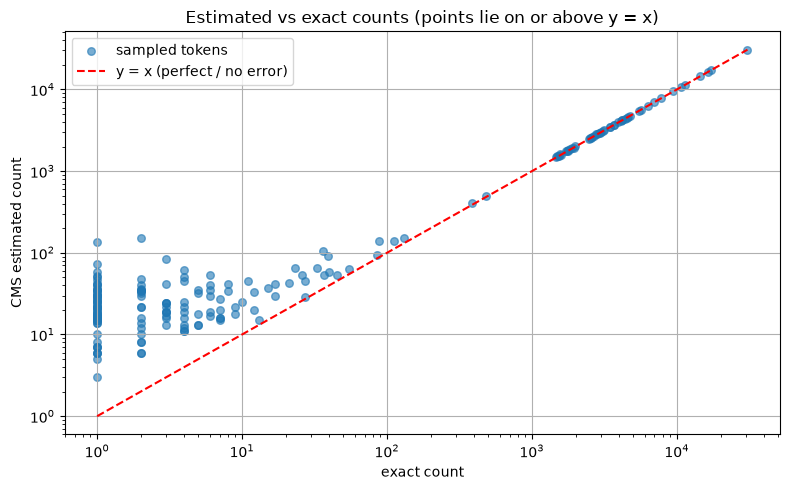

In [14]:
# --- Plot 1: estimated vs exact (log-log) --------------------------------
fig, ax = plt.subplots()
ax.scatter(val["exact_count"], val["estimated_count"], alpha=0.6, s=30,
           label="sampled tokens")
lim = max(val["exact_count"].max(), val["estimated_count"].max())
ax.plot([1, lim], [1, lim], "r--", label="y = x (perfect / no error)")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("exact count"); ax.set_ylabel("CMS estimated count")
ax.set_title("Estimated vs exact counts (points lie on or above y = x)")
ax.legend()
plt.tight_layout(); plt.show()

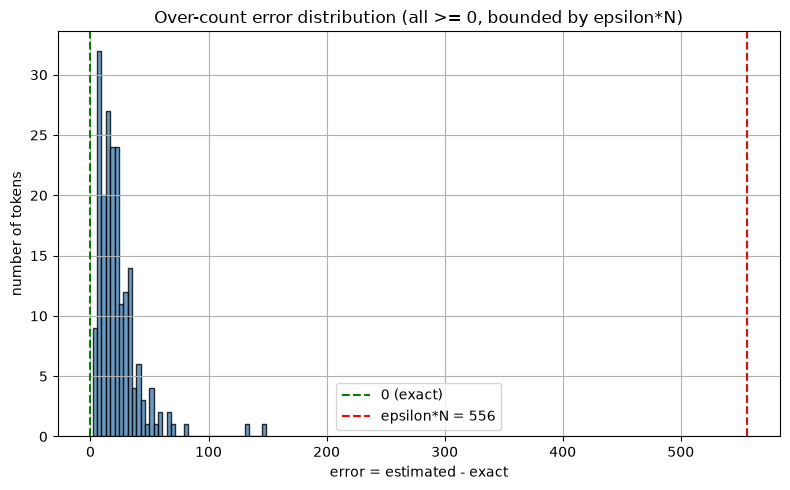

In [15]:
# --- Plot 2: over-count error distribution -------------------------------
fig, ax = plt.subplots()
ax.hist(val["error"], bins=40, color="steelblue", edgecolor="black", alpha=0.8)
ax.axvline(0, color="green", linestyle="--", label="0 (exact)")
ax.axvline(bound, color="red", linestyle="--", label=f"epsilon*N = {bound:,.0f}")
ax.set_xlabel("error = estimated - exact"); ax.set_ylabel("number of tokens")
ax.set_title("Over-count error distribution (all >= 0, bounded by epsilon*N)")
ax.legend()
plt.tight_layout(); plt.show()

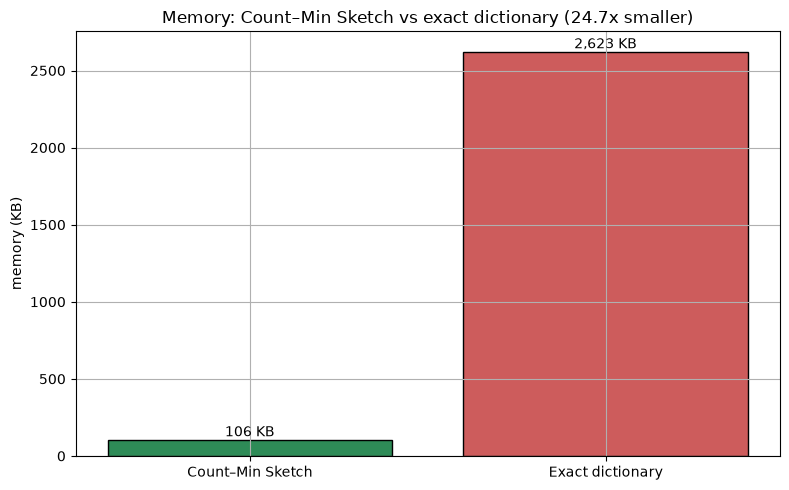

In [16]:
# --- Plot 3: memory comparison -------------------------------------------
fig, ax = plt.subplots()
bars = ax.bar(mem["structure"], mem["KB"],
              color=["seagreen", "indianred"], edgecolor="black")
ax.set_ylabel("memory (KB)")
ax.set_title(f"Memory: Count–Min Sketch vs exact dictionary ({ratio:.1f}x smaller)")
for b, kb in zip(bars, mem["KB"]):
    ax.text(b.get_x() + b.get_width()/2, kb, f"{kb:,.0f} KB",
            ha="center", va="bottom")
plt.tight_layout(); plt.show()

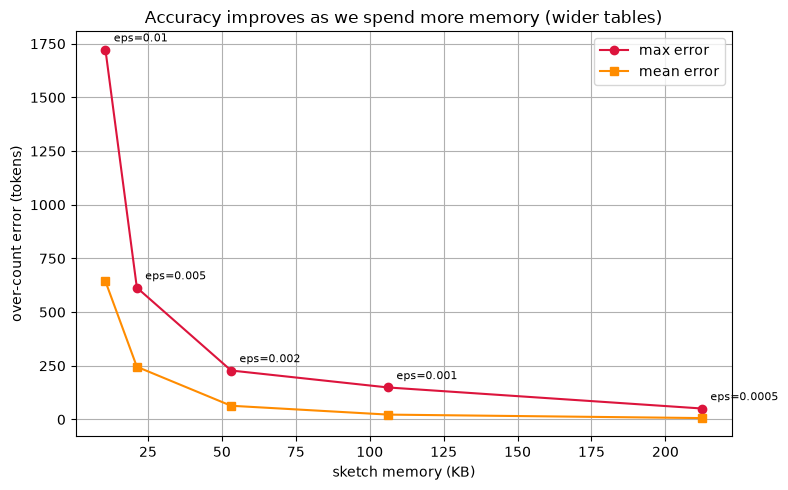

In [17]:
# --- Plot 4: parameter sweep (error vs memory) ---------------------------
fig, ax1 = plt.subplots()
ax1.plot(sweep["memory_KB"], sweep["max_error"], "o-", color="crimson",
         label="max error")
ax1.plot(sweep["memory_KB"], sweep["mean_error"], "s-", color="darkorange",
         label="mean error")
ax1.set_xlabel("sketch memory (KB)")
ax1.set_ylabel("over-count error (tokens)")
ax1.set_title("Accuracy improves as we spend more memory (wider tables)")
for _, r in sweep.iterrows():
    ax1.annotate(f"eps={r['epsilon']}", (r["memory_KB"], r["max_error"]),
                 textcoords="offset points", xytext=(6, 6), fontsize=8)
ax1.legend()
plt.tight_layout(); plt.show()

## 14. Conclusion

**What we built.** A from-scratch Count–Min Sketch with Carter–Wegman universal
hashing and a deterministic polynomial token→integer map, driven by a genuine
line-by-line, token-by-token stream over several Project Gutenberg books, with a
companion heavy-hitter tracker for top-*k*.

**What the results show.**

- **Correctness / one-sided error.** Across the validation sample *no* token was
  ever under-counted — every estimate satisfied `est ≥ exact`, and all points sit
  on or above the `y = x` line.
- **Bounded over-count.** Observed errors respected the `ε·N` guarantee, and the
  parameter sweep confirmed the predicted trade-off: wider tables (more memory)
  drive the over-count down roughly in proportion to `1/w`.
- **Memory.** The sketch occupies a small, *fixed* footprint set purely by
  `d` and `w`, using many times less memory than the exact dictionary — and,
  unlike the dictionary, it does **not** grow with the vocabulary or stream
  length.
- **Top-*k*.** Paired with a lightweight tracker, the sketch recovers the true
  most-frequent words with high overlap, despite never storing the words in the
  counting structure itself.

**Trade-offs & limitations.** CMS cannot enumerate items on its own; it only
answers point queries, so a helper structure is needed for top-*k*. It
over-counts (never under-counts), and the error is largest for rare items
sharing buckets with frequent ones — which is exactly why the *minimum* across
rows and a sufficiently large `w` matter.

**Reproducibility.** Every random choice (hash coefficients, validation sample)
is derived from a single `SEED`, the token→integer map is deterministic, and the
notebook runs top-to-bottom from a clean state, downloading (and caching) its own
data. Re-running yields identical tables and plots.
